In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
%load_ext autoreload  
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
%matplotlib inline

In [160]:
import math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import os
import time

from typing import Iterable
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms

from torch.optim import lr_scheduler

import sys 
import gc
for p in ['../..']:
    if p not in sys.path:
        # print(f"insert {p}")
        sys.path.insert(0, p)
print(sys.path)

from training_code import *
from wandb_helper import wandb_init, wandb_log_metrics,wandb_watch, wandb_end
from types import SimpleNamespace

from torchinfo import summary
from models import *
summary_col_names = ("input_size",
            "output_size",
            "num_params",
            # "params_percent",
            "kernel_size",
            "mult_adds",
            "trainable" )

['../..', '/home/kbardool/miniconda3/envs/opencv/lib/python312.zip', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/lib-dynload', '', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/site-packages', '/tmp/tmpp83ddqw8']


In [161]:
from torchvision import datasets

### <font style="color:green">Create a Dataset Object </font>

In [5]:
train_data = datasets.ImageFolder("./cat-dog-panda/training")
validation_data = datasets.ImageFolder("./cat-dog-panda/validation")
print(type(train_data))

<class 'torchvision.datasets.folder.ImageFolder'>


 ## <font style="color:blue">3.3. Data Loaders </font>

### <font style="color:green">3.3.1. Data Loader for Full Data</font>

Data loader used by the training routine to  generate batches of data:

In [6]:
def data_loader(data_root, transform, batch_size=16, shuffle=False, num_workers=2):
    dataset = datasets.ImageFolder(root=data_root, transform=transform)
    
    loader = torch.utils.data.DataLoader(dataset, 
                                         batch_size=batch_size,
                                         num_workers=num_workers,
                                         shuffle=shuffle)
    
    return loader

### <font style="color:green">3.3.2. Data Loader for Subset</font>
Data loader which uses the `subset` to generate batches

In [7]:
def subset_data_loader(data_root, transform, batch_size=8, shuffle=False, num_workers=2, subset_size=0.05):
    dataset = datasets.ImageFolder(root=data_root, transform=transform)
    
    data_subset = torch.utils.data.Subset(dataset,np.arange(0,len(dataset),1./subset_size).astype(int))

    loader = torch.utils.data.DataLoader(data_subset, 
                                         batch_size=batch_size,
                                         num_workers=num_workers,
                                         shuffle=shuffle)
    
    return loader

 ## <font style="color:blue">3.2. Image Transforms</font>

We need to normalize the data. Some of the  standard ways of doing it is to, subtract the mean, make all images equal in size or to rescale the range to \[0,1\] etc. , Use the following functions to do this:

- just like `image_preprocess_transforms`, `image_common_transforms` should also be applied _**irrespective of whether we have training set or validation set**_!
- However since **data augmentation** would be applicable to the **training set** only, you should write a separate function for that!
- Normalization is usually the last preprocessing step to be performed before training

 ### <font style="color:green">3.2.1. Compulsary Preprocessing Transforms</font>

In [163]:
def image_preprocess_transforms():
    
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
        ])
    
    return preprocess

  ### <font style="color:green">3.2.2. Common Image Transforms</font>
Normalize for mean and std. 

You can add any other transforms here as per your dataset.

In [205]:
def image_common_transforms(mean=(0.4611, 0.4359, 0.3905), 
                            std=(0.2193, 0.2150, 0.2109)):
    
    preprocess = image_preprocess_transforms()
    
    common_transforms = transforms.Compose([
        preprocess,
        transforms.Normalize(mean, std)
    ])
    
    return common_transforms
    

  ### <font style="color:green">3.2.3. Training data augmentation</font>
Normalize for mean and std. 

You can add any other transforms here as per your dataset.

In [204]:
class MyRandomAugmentations(torch.nn.Module):
    def forward(self,img ):
        
        new_image = v2.RandomChoice(transforms=[
                       v2.ElasticTransform(alpha=100.0, sigma = 5.0),
                       v2.RandomResizedCrop(size=(224, 224), scale=(0.0,1.0)),
                       v2.RandomHorizontalFlip(p=0.5),
                       v2.RandomRotation(degrees=45)], p=[0.2,0.2,0.2,0.2])(img)
        return new_image 

In [217]:
from torchvision.transforms import v2

def data_augmentation_preprocess(mean=(0.4611, 0.4359, 0.3905), 
                            std=(0.2193, 0.2150, 0.2109)):
    # transforms.Compose([
        # v2.ToImage(),
        # v2.RandomPhotometricDistort(p=1),
        # v2.RandomZoomOut(fill={tv_tensors.Image: (123, 117, 104), "others": 0}),
        # v2.RandomIoUCrop(),
        # v2.RandomHorizontalFlip(p=1),
        # v2.SanitizeBoundingBoxes(),
        # v2.ToDtype(torch.float32, scale=True),
        # v2.RandomResizedCrop(size=224, scale = )
    # ])
    augmentation_options=[v2.ElasticTransform(alpha=100.0, sigma = 5.0),
                        v2.RandomResizedCrop(size=(224, 224), scale=(0.0,1.0)),
                        v2.RandomHorizontalFlip(p=1.0),
                        v2.RandomRotation(degrees=45)]
    # data_augmentations = MyRandomAugmentations()
    preprocess = image_preprocess_transforms()
    
    _transforms = v2.Compose([
        transforms.RandomChoice(transforms=augmentation_options, p=[0.25, 0.25, 0.25, 0.25]), 
        preprocess,
        transforms.Normalize(mean, std)
    ])
    
    return _transforms
    

  ### <font style="color:green">3.2.3. Mean and STD</font>
Function for getting mean and variance

In [206]:
def get_mean_std(data_root, num_workers=4):
    
    transform = image_preprocess_transforms()
    
    loader = data_loader(data_root, transform)
    
    batch_mean = torch.zeros(3)
    batch_mean_sqrd = torch.zeros(3)
    
    for batch_data, _ in loader:
        batch_mean += batch_data.mean(dim=(0, 2, 3)) # E[batch_i] 
        batch_mean_sqrd += (batch_data ** 2).mean(dim=(0, 2, 3)) #  E[batch_i**2]
    
    # E[dataset] = E[E[batch_1], E[batch_2], ...]
    mean = batch_mean / len(loader)
    
    # var[X] = E[X**2] - E[X]**2
    
    # E[X**2] = E[E[batch_1**2], E[batch_2**2], ...]
    # E[X]**2 = E[E[batch_1], E[batch_2], ...] ** 2
    
    var = (batch_mean_sqrd / len(loader)) - (mean ** 2)
    std = var ** 0.5
    
    return mean, std

In [183]:
# print(f" train & validation      : mean: {me}   std: {st}")
# me, st = get_mean_std('./cat-dog-panda/training')
# print(f" training mean and std   : mean: {me}   std: {st}")
# me, st = get_mean_std('./cat-dog-panda/validation')
# print(f" validation mean and std : mean: {me}   std: {st}")
# me, st = get_mean_std('./cat-dog-panda')

In [184]:
import math
plt.style.use('default')
 
def plot_transformed_images(images, unnormalize = False):
    fig = plt.figure(figsize=(18,6))
    cols = len(images)    
    for i,img in enumerate(images):
        _ = plt.subplot(1, cols, i+1)
        if unnormalize:
           img -= img.min()
           img /= img.max()           
        _ = plt.imshow(torch.moveaxis(img,0,-1))
        # print(f" {img.shape}  {torch.moveaxis(img,0,-1).shape}")
        # img = transforms.functional.to_pil_image(imgs[i])
    plt.show()


def plot_raw_images(images):    
    rows = math.ceil(len(images)/6.0)
    cols = min(len(images),6)
    fig = plt.figure(figsize=(18,rows*6))  
    
    for i, (img,label)  in enumerate(images):
        # img = image_data[idx][0]
        # print(f"      {transforms.functional.to_pil_image(img).shape}")
        _ = plt.subplot(rows, cols , i+1)
        _ = plt.imshow(img)
        _ = plt.gca().set_title('idx:{0}  {1}  size:{2})'.format(i, 
                                                     train_data.classes[label],
                                                     img.size),
                                                     fontsize=9)
    plt.show()

  ### <font style="color:green"> 3.2.4 Prepare Data Loaders</font>
The main function which uses all the above functions to generate the train and test dataloaders.


In [207]:
def get_data(batch_size, data_root, num_workers=4, data_augmentation=False):
    
    train_data_path = os.path.join(data_root, 'training')
       
    mean, std = get_mean_std(data_root=train_data_path, num_workers=num_workers)
    print(f" mean: {mean}         str: {std}")
    common_transforms = image_common_transforms(mean, std)
        
   
    # if data_augmentation is true 
    # data augmentation implementation
    if data_augmentation:    
        train_transforms = data_augmentation_preprocess(mean, std)
    # else do common transforms
    else:
        train_transforms = common_transforms
        
        
    # train dataloader
    
    train_loader =  data_loader(train_data_path, 
                               train_transforms, 
                               batch_size=batch_size, 
                               shuffle=False, 
                               num_workers=num_workers)
    
    # test dataloader
    
    test_data_path = os.path.join(data_root, 'validation')
    
    test_loader =  data_loader(test_data_path, 
                              train_transforms, 
                              batch_size=batch_size, 
                              shuffle=False, 
                              num_workers=num_workers)
    
    return train_loader, test_loader

In [211]:
# data loader
BATCH_SIZE = 5
DATA_ROOT = './cat-dog-panda'

In [218]:
train_loader, test_loader = get_data(
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    num_workers=0,
    data_augmentation=True
)

 SubsetSize: 1.000000   Dataset size: 2400
 mean: tensor([0.4610, 0.4347, 0.3897])         str: tensor([0.2734, 0.2641, 0.2616])
 SubsetSize: 1.000000   Dataset size: 2400
 SubsetSize: 1.000000   Dataset size: 600


In [213]:
for batch_idx, (data, target) in enumerate(train_loader):
    idxs = np.arange(batch_idx*BATCH_SIZE, batch_idx*BATCH_SIZE+3 )    
    print(idxs)
    print(f"batch_idx : {batch_idx}    img indexes: {idxs}  - - - target: {target}   data: {type(data)}   data shape: {data.shape}")

    break

[0 1 2]
batch_idx : 0    img indexes: [0 1 2]  - - - target: tensor([0, 0, 0, 0, 0])   data: <class 'torch.Tensor'>   data shape: torch.Size([5, 3, 224, 224])


In [219]:
batch_idx = -1
train_loader_iter = iter(train_loader)

In [225]:
data,target = next(train_loader_iter)
batch_idx +=1
print(f"batch_idx : {batch_idx}    img indexes: {idxs}  - - - target: {target}   data: {type(data)}   data shape: {data.shape}")

batch_idx : 2    img indexes: [0 1 2]  - - - target: tensor([0, 0, 0, 0, 0])   data: <class 'torch.Tensor'>   data shape: torch.Size([5, 3, 224, 224])


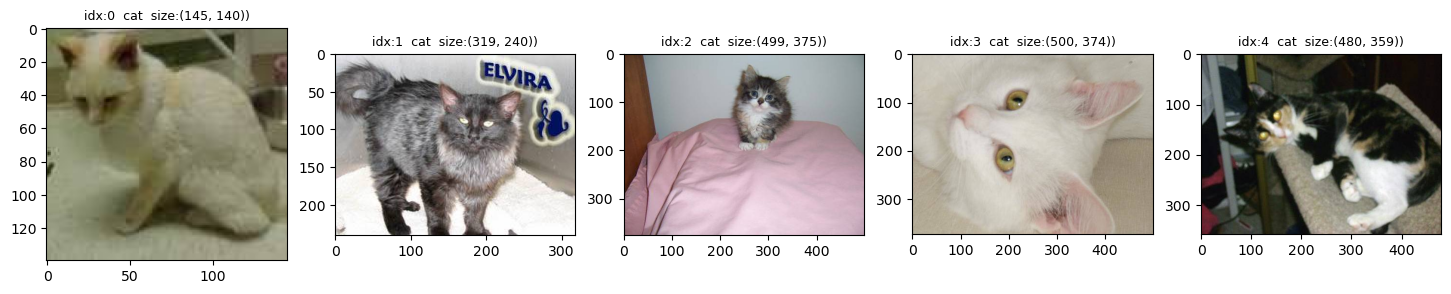

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6311212..1.1010029].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6859332..2.3327708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3417071..2.0629728].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6859332..2.0929503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6142194..2.3177824].


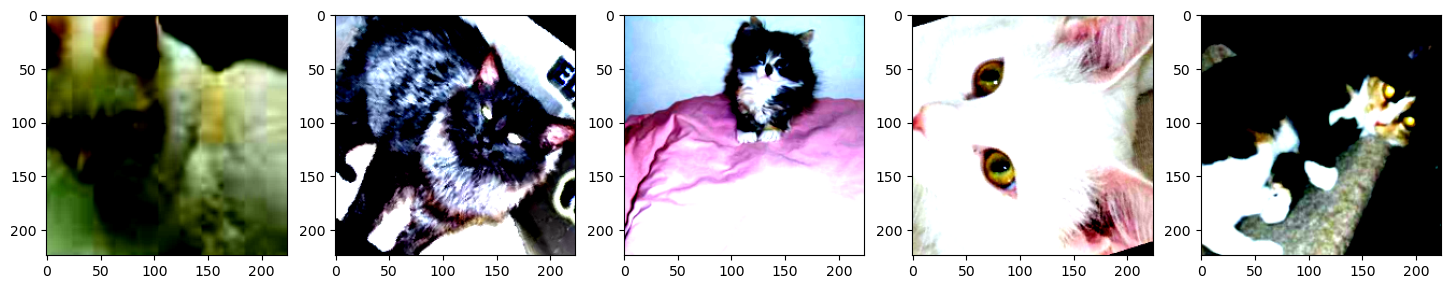

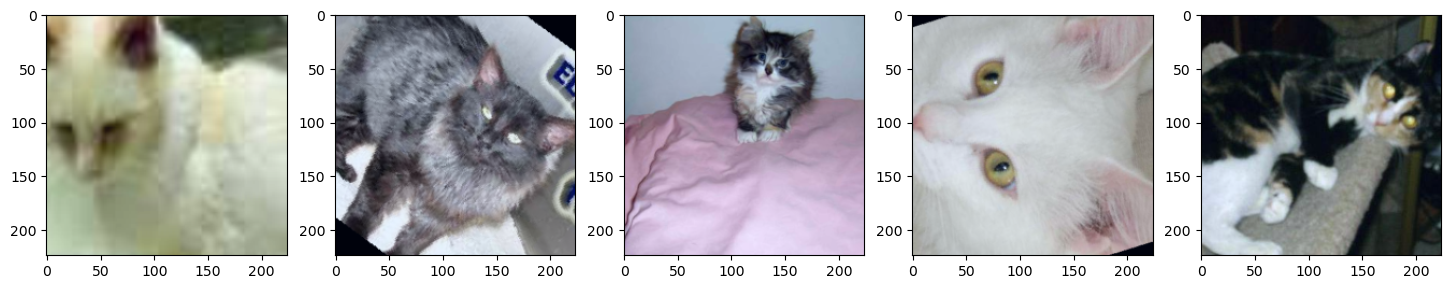

In [226]:
raw_images= [train_data[i]  for i in np.arange(batch_idx*BATCH_SIZE, (batch_idx+1)*BATCH_SIZE)]
plot_raw_images(raw_images)
plot_transformed_images(data)
plot_transformed_images(data, unnormalize=True)

In [143]:
# print(type(train_data[0][0]), train_data[0][0].format, train_data[0][0].mode) 
# print(train_data[0][0].info, train_data[0][0].getextrema())
# pil_np = np.array(train_data[0][0])
# print(f" {pil_np.shape}     min: {pil_np.min()}  max: {pil_np.max()}  mean: {pil_np.mean()}   std: {pil_np.std()}")
 
# tensor = transforms.ToTensor()(train_data[0][0])
# print(f" {tensor.shape}   {tensor.dtype}   -   min: {tensor.min()}  max: {tensor.max()}  mean: {tensor.mean()}   std: {tensor.std()}")
# tensor = transforms.functional.to_tensor(train_data[0][0])
# print(f" {tensor.shape}   {tensor.dtype}   -   min: {tensor.min()}  max: {tensor.max()}  mean: {tensor.mean()}   std: {tensor.std()}")
# norm_tensor = transforms.functional.normalize(tensor, mean=[0.4610, 0.4347, 0.3897] , std=[0.2734, 0.2641, 0.2616])
# print(f" {norm_tensor.shape}   {norm_tensor.dtype}   -   min: {norm_tensor.min()}  max: {norm_tensor.max()}  mean: {norm_tensor.mean()}   std: {norm_tensor.std()}")

# plt.imshow( torch.moveaxis(tensor,0,-1))
# plt.imshow( torch.moveaxis(norm_tensor,0,-1))

In [144]:
print(type(data[0]), data[0].shape)
print(data[0].min(), data[0].max(), data[0].mean(), data[0].std())
print(data[0,0].mean() , data[0,1].mean() , data[0,2].mean())



<class 'torch.Tensor'> torch.Size([3, 224, 224])
tensor(-1.6014) tensor(1.8232) tensor(0.0611) tensor(0.7210)
tensor(0.3273) tensor(-0.0562) tensor(-0.0877)


### <font style="color:green">Display Some Samples</font>
Display one sample from each class. We know that the train dataset contains 

- cats from 0 to 799
- dogs from 800 to 1599
- pandas from 1600 to 2399

Take one sample from each class and display using matplotlib

[468 145 525] <class 'numpy.ndarray'>


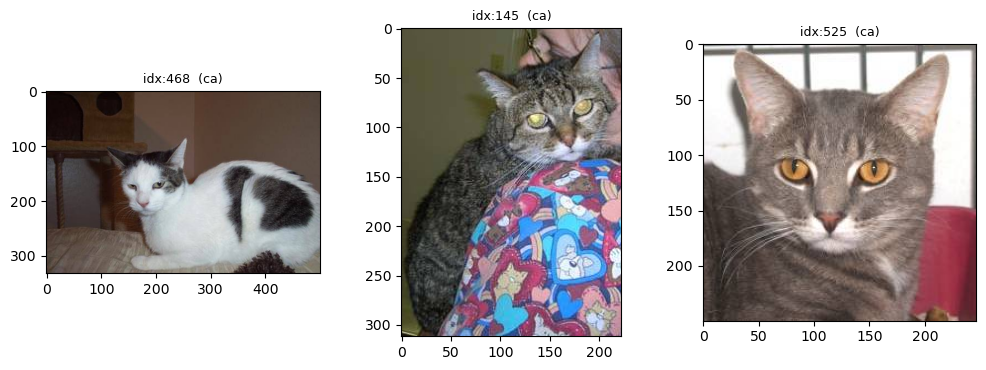

In [79]:
# Enter Code Here
idxs = np.random.randint(0,800,3)
print(idxs, type(idxs))
plot_by_idxs(idxs)

In [30]:
print (idxs)
idx = 438

[645 543 701]


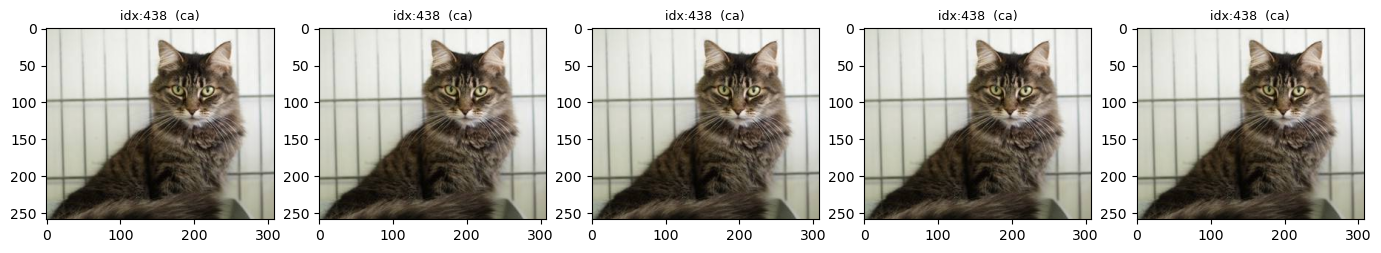

In [37]:
plt.style.use('default')
plt.rcParams["figure.figsize"] = (18, 6)
fig = plt.figure(figsize=(17, 6))
    
for i in range(5):
    _ = plt.subplot(1, 5, i+1)
    # img = transforms.functional.to_pil_image(imgs[i])
    _ = plt.imshow(train_data[idx][0])
    _ = plt.gca().set_title('idx:{0}  ({1:.2})'.format(idx, 
                                                 train_data.classes[train_data[idx][1]]), fontsize=9)